In [1]:
import pandas as pd
from collections import defaultdict
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
import random


In [2]:
nyc_train = pd.read_csv("../data/processed/training_data_city_nyc-full__trainWindow_210__.csv", index_col=0)
tky_train = pd.read_csv("../data/processed/training_data_city_tky-full__trainWindow_210__.csv", index_col=0)

algorithms = ["ItemKNN", "MultiVAE"]
ps = [0.0,1.0]
seed = 500
version = "full"
t_window = 210
k_days = 7
topK = 20
max_simulation_days = 104
city = "nyc"

In [9]:


# Set seed for reproducibility
random.seed(42)

# Define expected column names for the user history files
new_columns = [
    'uid', 'lat', 'lon', 'venueID', 'venue_descr', 'time', 'city_name',
    'First_Category', 'Second_Category', 'step', 'epoch', 'city', 'simulation_state'
]

# Gini index function
def gini_index(values):
    sorted_values = np.sort(values)
    n = len(sorted_values)

    if n == 0 or np.sum(sorted_values) == 0:
        return 0

    indices = np.arange(1, n + 1)
    gini = (2 * np.sum(indices * sorted_values)) / (n * np.sum(sorted_values)) - (n + 1) / n
    return gini

# Initialize result containers
gini_indices_by_category = {}
points_by_category = {}

# Loop over algorithms
for algorithm in algorithms:
    gini_indices_by_category[algorithm] = {}
    points_by_category[algorithm] = {}

    # Loop over recProb values
    for p in tqdm(ps, desc=f"Algorithm: {algorithm}"):
        # Build experiment directory path
        experiment_dir = f"../data/processed/experiments/{version}/{seed}/city_{city}__train_{t_window}__step_{k_days}__max_{max_simulation_days}__topK_{topK}__alg_{algorithm}__recProb_{p}"

        merged_user_histories = pd.DataFrame()

        # Load user history files for the current algorithm and recProb
        for user_fname in Path(experiment_dir).glob('user_histories/*.csv'):
            user_id = user_fname.stem.split('_')[0]
            user_history = pd.read_csv(user_fname, index_col=0)
            user_history = user_history.loc[:, ~user_history.columns.str.contains('^Unnamed')]
            
            if 'simulation_state' not in user_history.columns:
                continue  # Skip malformed files

            user_history.columns = new_columns
            user_history = user_history[user_history['simulation_state'].notnull()]
            merged_user_histories = pd.concat([merged_user_histories, user_history], ignore_index=True)

        # Compute Gini index and point counts per First_Category
        gini_per_category = {}
        points_per_category = {}

        for category in merged_user_histories['First_Category'].dropna().unique():
            category_visits = merged_user_histories[merged_user_histories['First_Category'] == category]

            # Count visits per unique (lat, lon)
            counts = category_visits.groupby(['lat', 'lon']).size().values

            gini_per_category[category] = gini_index(counts)
            points_per_category[category] = len(counts)


        # Store results
        gini_indices_by_category[algorithm][p] = gini_per_category
        points_by_category[algorithm][p] = points_per_category


Algorithm: ItemKNN:   0%|          | 0/2 [00:00<?, ?it/s]

Algorithm: MultiVAE:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
points_by_category["MultiVAE"][1.0]

{'Dining and Drinking': 2368,
 'Arts and Entertainment': 463,
 'Retail': 1140,
 'Travel and Transportation': 276,
 'Business and Professional Services': 442,
 'Sports and Recreation': 319,
 'Landmarks and Outdoors': 715,
 'Community and Government': 483,
 'Health and Medicine': 188,
 'Nightlife Spot': 13}

In [ ]:
# # Add a placeholder value for p = 'train'
# algorithm = 'train'
# gini_indices_by_category[algorithm] = {}
# p_value = 'prior'  # non-numeric to indicate it's not a simulation

# # Calculate Gini index per Second_Category in training set
# gini_per_category = {}

# for category in nyc_train['First_Category'].dropna().unique():
#     category_visits = nyc_train[nyc_train['First_Category'] == category]

#     # Group by location (lat, lon) to get spatial concentration of visits
#     counts = category_visits.groupby(['lat', 'lng']).size().values

#     gini_per_category[category] = gini_index(counts)

# # Add to dictionary
# gini_indices_by_category[algorithm][p_value] = gini_per_category


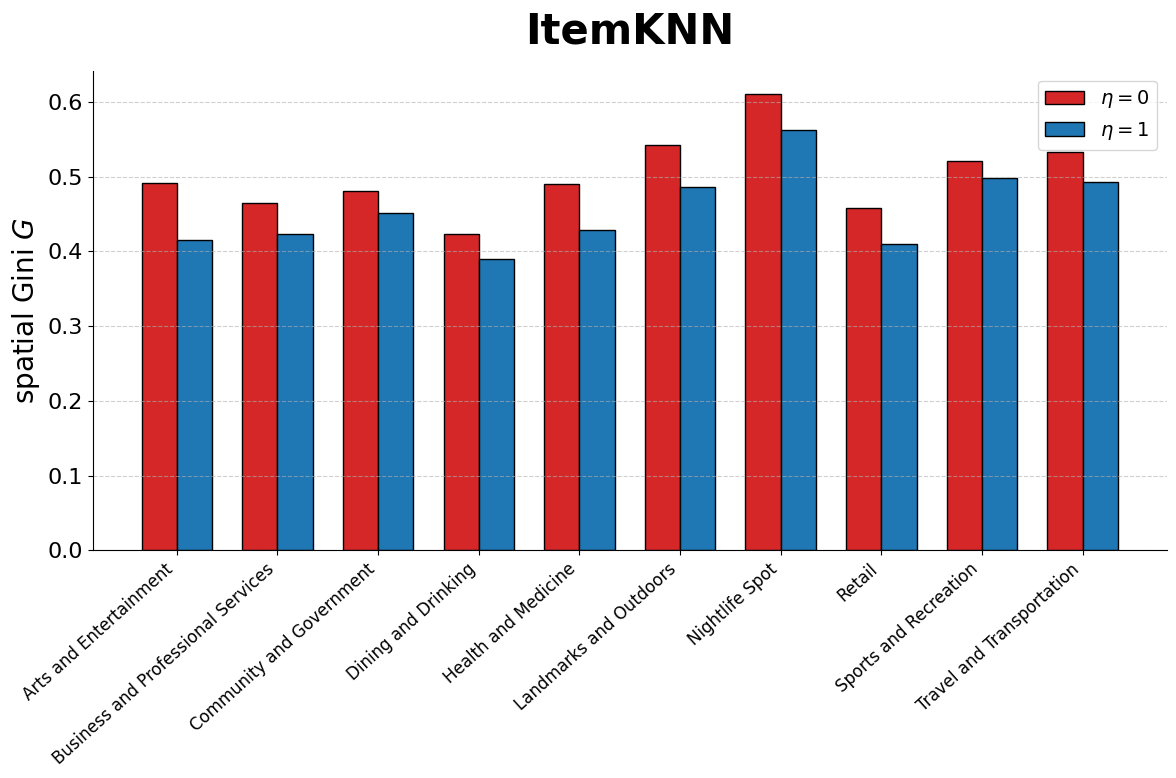

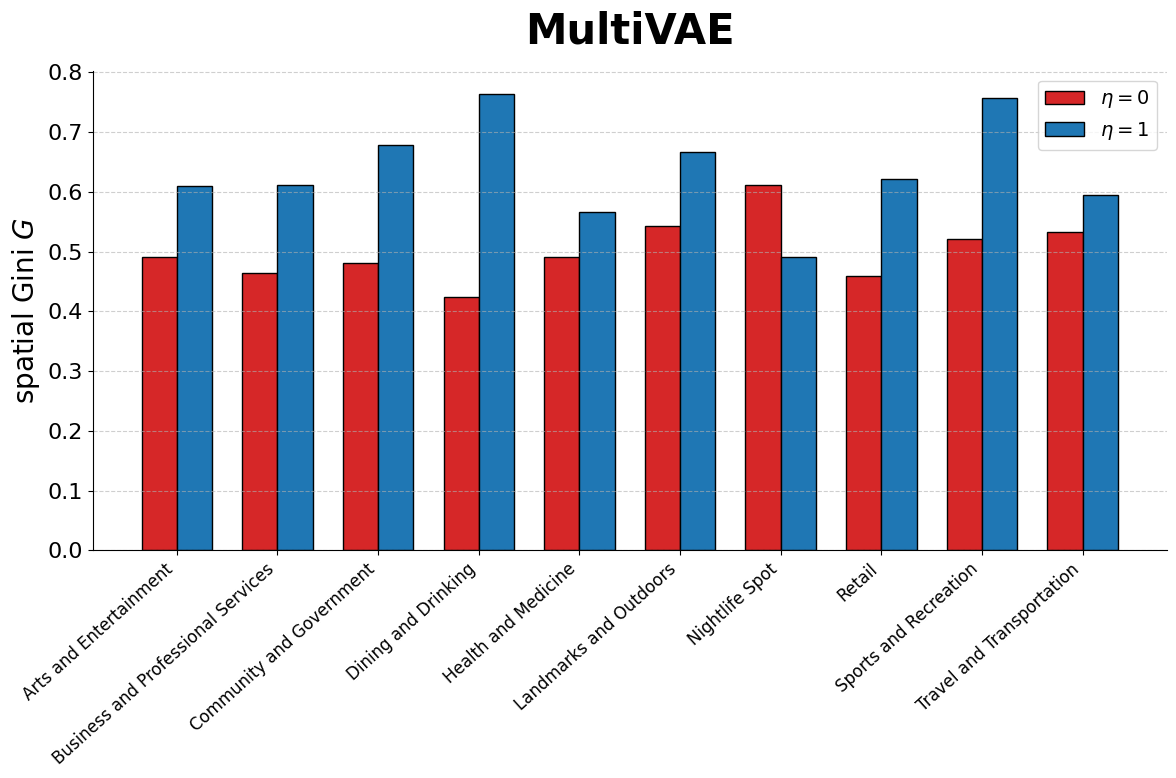

In [14]:
import matplotlib.pyplot as plt
import numpy as np



# === SET UP PLOTTING STYLES ===
plt.style.use('default')
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 20,
    'xtick.labelsize': 12,
    'ytick.labelsize': 16,
    'legend.fontsize': 14,
    'figure.figsize': (12, 8)
})

# === COLOR PALETTE ===
color_p1 = '#1f77b4'  # Cool blue
color_p0 = '#d62728'  # Deep red

# === PLOTTING LOOP ===
for algorithm in algorithms:
    p0_categories = set(gini_indices_by_category[algorithm][0.0].keys())
    p1_categories = set(gini_indices_by_category[algorithm][1.0].keys())
    common_categories = sorted(list(p0_categories & p1_categories))

    p0_ginis = [gini_indices_by_category[algorithm][0.0][cat] for cat in common_categories]
    p1_ginis = [gini_indices_by_category[algorithm][1.0][cat] for cat in common_categories]

    x = np.arange(len(common_categories))
    width = 0.35

    fig, ax = plt.subplots()
    ax.bar(x - width/2, p0_ginis, width=width, label=r'$\eta = 0$', edgecolor='black', color=color_p0)
    ax.bar(x + width/2, p1_ginis, width=width, label=r'$\eta = 1$', edgecolor='black', color=color_p1)

    # Axis formatting
    ax.set_xticks(x)
    ax.set_xticklabels(common_categories, rotation=42, ha='right')
    ax.set_ylabel(r'spatial Gini $G$')
    ax.set_title(f'{algorithm}', pad=20, fontsize=30, fontweight='bold')
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.6)

    # Remove top and right axes
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    plt.tight_layout()
    plt.show()


In [33]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# === COLOR SETUP ===
colors = {
    "ItemKNN": "goldenrod",
    "MultiVAE": "teal"
}

# === Build merged_user_histories for each (algorithm, p) ===
merged_histories_dict = {}  # (algorithm, p) -> DataFrame

for algorithm in algorithms:
    for p in ps:
        experiment_dir = f"../data/processed/experiments/{version}/{seed}/city_{city}__train_{t_window}__step_{k_days}__max_{max_simulation_days}__topK_{topK}__alg_{algorithm}__recProb_{p}"
        merged_user_histories = pd.DataFrame()

        for user_fname in Path(experiment_dir).glob('user_histories/*.csv'):
            user_history = pd.read_csv(user_fname, index_col=0)
            user_history = user_history.loc[:, ~user_history.columns.str.contains('^Unnamed')]
            if 'simulation_state' not in user_history.columns:
                continue
            user_history.columns = new_columns
            user_history = user_history[user_history['simulation_state'].notnull()]
            merged_user_histories = pd.concat([merged_user_histories, user_history], ignore_index=True)

        merged_histories_dict[(algorithm, p)] = merged_user_histories


In [46]:
gini_pct_change = {}
all_categories = set()

for algorithm in algorithms:
    gini_pct_change[algorithm] = {}
    p0_ginis = gini_indices_by_category[algorithm][0.0]
    p1_ginis = gini_indices_by_category[algorithm][1.0]
    shared_categories = set(p0_ginis.keys()) & set(p1_ginis.keys())
    all_categories.update(shared_categories)

    for cat in shared_categories:
        g0 = p0_ginis[cat]
        g1 = p1_ginis[cat]
        if g0 == 0:
            change = 0
        else:
            change = 100 * (g1 - g0) / g0
        gini_pct_change[algorithm][cat] = change

all_categories = sorted(all_categories)
all_categories.remove("Nightlife Spot")  # Exclude "Nightlife Spot" category


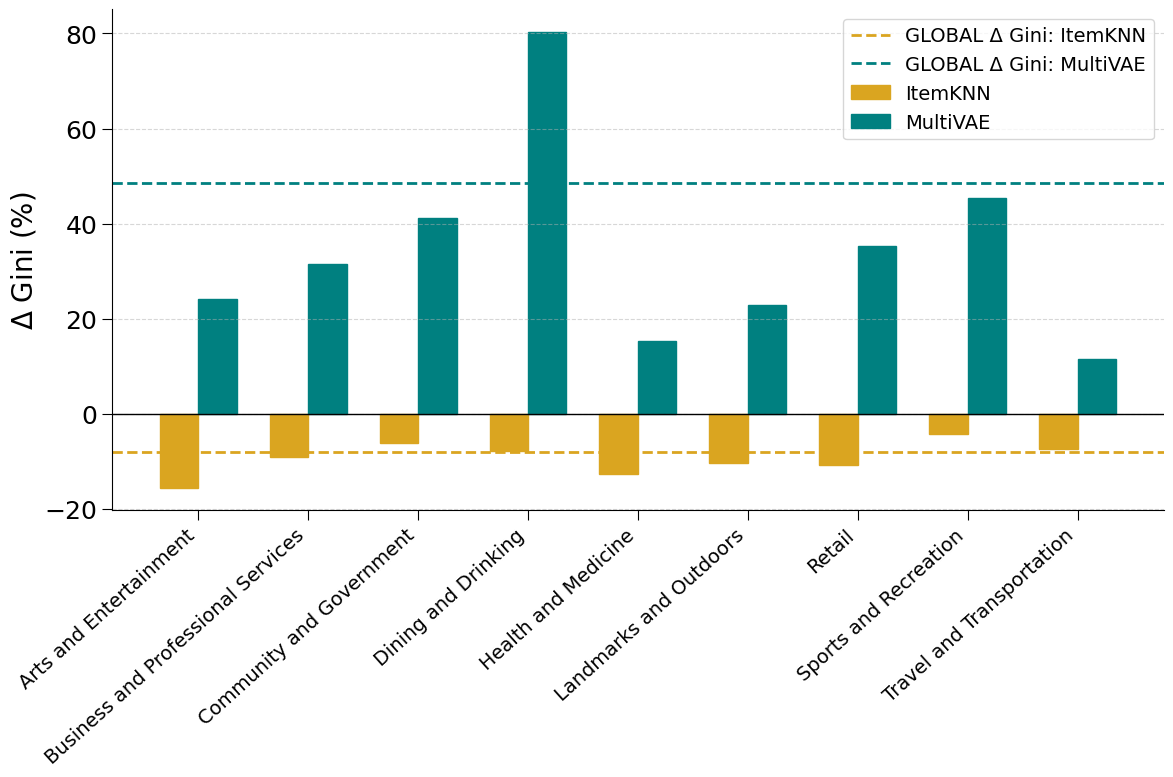

In [56]:
plt.style.use('default')
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 20,
    'xtick.labelsize': 14,
    'ytick.labelsize': 18,
    'legend.fontsize': 14,
    'figure.figsize': (12, 8),
    #increase ticksize
    'xtick.major.size': 7,
    'ytick.major.size': 7,
})



x = np.arange(len(all_categories))
width = 0.35

fig, ax = plt.subplots()
offsets = {
    algorithms[0]: -width / 2,
    algorithms[1]: width / 2
}

# === Bar plot ===
for algorithm in algorithms:
    y_vals = [gini_pct_change[algorithm].get(cat, 0) for cat in all_categories]
    ax.bar(x + offsets[algorithm], y_vals, width=width, label=algorithm,
           color=colors[algorithm], edgecolor=colors[algorithm])

# === GLOBAL Gini % increase lines ===
for algorithm in algorithms:
    df_0 = merged_histories_dict[(algorithm, 0.0)]
    df_1 = merged_histories_dict[(algorithm, 1.0)]

    # All location visit counts (no category filtering)
    counts_0 = df_0.groupby(['lat', 'lon']).size().values
    counts_1 = df_1.groupby(['lat', 'lon']).size().values

    gini_0 = gini_index(counts_0)
    gini_1 = gini_index(counts_1)

    if gini_0 == 0:
        perc_inc = 0
    else:
        perc_inc = 100 * (gini_1 - gini_0) / gini_0

    ax.axhline(perc_inc, linestyle='--', color=colors[algorithm], linewidth=2,
               label=f"GLOBAL Δ Gini: {algorithm}")


# === Final touches ===
ax.set_xticks(x)
ax.set_xticklabels(all_categories, rotation=42, ha='right')
ax.set_ylabel(r"$\Delta$ Gini (%)")
#ax.set_title("Category-wise Gini Change by Algorithm", fontsize=24, fontweight='bold', pad=20)
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Clean up spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Unique legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())
#solid black line on 0
ax.axhline(0, color='black', linewidth=1)

plt.tight_layout()
plt.show()


In [64]:
def load_user_history_of_category(experiment_dir, user_id, new_columns, category):
    """Loads a user's history, handles missing 'simulation_state', and cleans columns."""
    user_fname = Path(experiment_dir) / 'user_histories' / f'{user_id}_history.csv'
    if not user_fname.exists():
        return None

    user_history = pd.read_csv(user_fname, index_col=0)

    if 'simulation_state' not in user_history.columns:
        return None
    if "Unnamed: 0" in user_history.columns:
        user_history = user_history.drop(columns=["Unnamed: 0"])

    user_history.columns = new_columns
    user_history = user_history[user_history['simulation_state'].notnull()]
    #keep only the specified category
    if category:
        user_history = user_history[user_history['First_Category'] == category]
    return user_history

def get_users_with_50_plus_points_in_category(experiment_dir, new_columns, category, bounds):
    """Calculates and returns a list of user IDs with 150 or more points within the given bounds."""
    user_files = list(Path(experiment_dir).glob('user_histories/*.csv'))
    users_50_plus = []

    for user_fname in user_files:
        user_id = user_fname.stem.split('_')[0]
        user_history = pd.read_csv(user_fname, index_col=0)

        if 'simulation_state' not in user_history.columns:
            continue
        if "Unnamed: 0" in user_history.columns:
            user_history = user_history.drop(columns=["Unnamed: 0"])

        user_history.columns = new_columns
        user_history = user_history[user_history['simulation_state'].notnull()]
        #DROP duplicate lat/lon
        user_history = user_history.drop_duplicates(subset=['lat', 'lon'])
        if category:
            user_history = user_history[user_history['First_Category'] == category]

        within_bounds = user_history[
            (user_history['lat'] >= bounds['lat_min']) &
            (user_history['lat'] <= bounds['lat_max']) &
            (user_history['lon'] >= bounds['lon_min']) &
            (user_history['lon'] <= bounds['lon_max'])
        ]

        if len(within_bounds) >= 20:
            users_50_plus.append(user_id)

    return users_50_plus

def plot_user_visits_of_category(ax, user_history, cmap, vmin, vmax, category):
    """Plots user visits as scatter points, with size and color indicating frequency."""
    if user_history is not None and not user_history.empty:
        # Filter by category if provided
        if category:
            user_history = user_history[user_history['First_Category'] == category]
        counts = user_history.groupby(['lon', 'lat']).size().reset_index(name='visits')

        gini_counts = gini_index(counts['visits'])

        counts['marker_size'] = 110 + 330 * (counts['visits'] - vmin) / (vmax - vmin) if vmax > vmin else 110

        # Sort values so larger points are plotted on top
        counts = counts.sort_values(by="visits", ascending=True)

        edgecolor = 'red'
        
        scatter = ax.scatter(counts['lon'], counts['lat'], s=counts['marker_size'], c=counts['visits'], cmap=cmap, alpha=0.95, edgecolor=edgecolor, linewidth=0.4, vmin=vmin, vmax=vmax)
        #add text with gini index
        ax.text(0.8, 0.95, f"Gini: {gini_counts:.2f}", transform=ax.transAxes, fontsize=16, ha='center', va='top', color='black', bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round'))
        # Add colorbar
        return scatter
    elif user_history is None:
        print("User history is missing or incomplete.")
    else:
        print("User history is empty.")
    return None

def load_and_merge_active_user_histories(experiment_dir, new_columns, user_ids):
    """Loads and merges user histories for the given user IDs."""
    merged_user_histories = pd.DataFrame()

    for user_fname in Path(experiment_dir).glob('user_histories/*.csv'):
        user_id = user_fname.stem.split('_')[0]
        if user_id not in user_ids:
            continue

        user_history = pd.read_csv(user_fname, index_col=0)

        if 'simulation_state' not in user_history.columns:
            continue
        if "Unnamed: 0" in user_history.columns:
            user_history = user_history.drop(columns=["Unnamed: 0"])
        user_history.columns = new_columns
        user_history = user_history[user_history['simulation_state'].notnull()]
        merged_user_histories = pd.concat([merged_user_histories, user_history], ignore_index=True)

    return merged_user_histories

def plot_collective_visits(ax, location_counts, cmap, vmin, vmax, min_threshold=1):
    """Plots collective visits with shared scale and a minimum visit threshold."""
    if not location_counts.empty:

        location_counts = location_counts[location_counts['visits'] >= min_threshold]  # Apply threshold
        gini_counts = gini_index(location_counts['visits'])

        if not location_counts.empty:

            location_counts['marker_size'] = 110 + 330 * (location_counts['visits'] - vmin) / (vmax - vmin) if vmax > vmin else 110

            # Sort values so larger points are plotted on top
            location_counts = location_counts.sort_values(by="visits", ascending=True)

            edgecolor = 'dodgerblue'
            scatter = ax.scatter(location_counts['lon'], location_counts['lat'], s=location_counts['marker_size'], c=location_counts['visits'], cmap=cmap, alpha=0.95, edgecolor=edgecolor, linewidth=0.4, vmin=vmin, vmax=vmax)

            # Add text with Gini index
            ax.text(0.8, 0.95, f"Gini: {gini_counts:.2f}", transform=ax.transAxes, fontsize=16, ha='center', va='top', color='black',  bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round'))

            # Add colorbar
            return scatter
        else:
            print(f"No collective visit data above threshold {min_threshold}.")
    else:
        print("No collective visit data.")
    return None


In [65]:
#%%script false --no-raise-error

algorithm = "MultiVAE"

new_columns = ['uid', 'lat', 'lon', 'venueID', 'venue_descr', 'time', 'city_name', 'First_Category', 'Second_Category', 'step', 'epoch', 'city', 'simulation_state']

nyc_bounds = {
    'lat_min': 40.69,
    'lat_max': 40.80,
    'lon_min': -74.02,
    'lon_max': -73.92
}


tky_bounds = {
    'lat_min': 35.6388,
    'lat_max': 35.7488,
    'lon_min': 139.6534,
    'lon_max': 139.7534
}


if city == 'nyc':
    city_bounds = nyc_bounds
elif city == 'tky':
    city_bounds = tky_bounds



p = 0.0
experiment_dir_p0 = f"../data/processed/experiments/{version}/{seed}/city_{city}__train_{t_window}__step_{k_days}__max_{max_simulation_days}__topK_{topK}__alg_{algorithm}__recProb_{p}"
user_files_p0 = list(Path(experiment_dir_p0).glob('user_histories/*.csv'))
user_ids_p0 = {fname.stem.split('_')[0] for fname in user_files_p0}

p = 1.0
experiment_dir_p1 = f"../data/processed/experiments/{version}/{seed}/city_{city}__train_{t_window}__step_{k_days}__max_{max_simulation_days}__topK_{topK}__alg_{algorithm}__recProb_{p}"
user_files_p1 = list(Path(experiment_dir_p1).glob('user_histories/*.csv'))
user_ids_p1 = {fname.stem.split('_')[0] for fname in user_files_p1}


category = "Dining and Drinking"
populed_users = get_users_with_50_plus_points_in_category(experiment_dir_p0, new_columns, category, city_bounds)

random_user_id = populed_users[2]
user_history_p0 = load_user_history_of_category(experiment_dir_p0, random_user_id, new_columns, category)
user_history_p1 = load_user_history_of_category(experiment_dir_p1, random_user_id, new_columns, category)

shared_user_ids = sorted(list(user_ids_p0.intersection(user_ids_p1)))
sorted_shared_user_ids = sorted(shared_user_ids) #sort the list
random.seed(49)
sampled_shared_user_ids = random.sample(shared_user_ids, min(250, len(sorted_shared_user_ids)))


merged_user_histories_p0 = load_and_merge_active_user_histories(experiment_dir_p0, new_columns, sampled_shared_user_ids)
#keep only the correct category
merged_user_histories_p0 = merged_user_histories_p0[merged_user_histories_p0['First_Category'] == category]
location_counts_p0 = merged_user_histories_p0.groupby(['lat', 'lon']).size().reset_index(name='visits')

merged_user_histories_p1 = load_and_merge_active_user_histories(experiment_dir_p1, new_columns, sampled_shared_user_ids)
#keep only the correct category
merged_user_histories_p1 = merged_user_histories_p1[merged_user_histories_p1['First_Category'] == category]
location_counts_p1 = merged_user_histories_p1.groupby(['lat', 'lon']).size().reset_index(name='visits')

individual_vmin = min(user_history_p0.groupby(['lon', 'lat']).size().min(), user_history_p1.groupby(['lon', 'lat']).size().min())
individual_vmax = max(user_history_p0.groupby(['lon', 'lat']).size().max(), user_history_p1.groupby(['lon', 'lat']).size().max())

collective_vmin = min(location_counts_p0['visits'].min(), location_counts_p1['visits'].min())
collective_vmax = max(location_counts_p0['visits'].max(), location_counts_p1['visits'].max())


# Calculate individual Gini
ps = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
individual_gini_dict = {}
for p in ps:
    experiment_dir = f"../data/processed/experiments/{version}/{seed}/city_{city}__train_{t_window}__step_{k_days}__max_{max_simulation_days}__topK_{topK}__alg_{algorithm}__recProb_{p}"
    user_history = load_user_history_of_category(experiment_dir, random_user_id, new_columns, category)
    if user_history is not None and not user_history.empty:
        individual_gini_dict[p] = gini_index(user_history.groupby('venueID').size())
    else:
        individual_gini_dict[p] = 0

# Calculate collective Gini
collective_gini_dict = {}
for p in ps:
    experiment_dir = f"../data/processed/experiments/{version}/{seed}/city_{city}__train_{t_window}__step_{k_days}__max_{max_simulation_days}__topK_{topK}__alg_{algorithm}__recProb_{p}"
    
    # Use the same sample of users consistently
    merged_user_histories = load_and_merge_active_user_histories(experiment_dir, new_columns, sampled_shared_user_ids)
    
    # Apply the same filtering as in plot_collective_visits
    if not merged_user_histories.empty:
        # Group by lat, lon (same as in plot_collective_visits)
        location_counts = merged_user_histories.groupby(['lat', 'lon']).size().reset_index(name='visits')
        
        # Apply the same threshold as used in plot_collective_visits (min_threshold=3)
        location_counts = location_counts[location_counts['visits'] >= 3]
        
        if not location_counts.empty:
            collective_gini_dict[p] = gini_index(location_counts['visits'])
        else:
            collective_gini_dict[p] = 0
    else:
        collective_gini_dict[p] = 0


/tmp/ipykernel_2564217/1692291742.py:112: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  location_counts['marker_size'] = 110 + 330 * (location_counts['visits'] - vmin) / (vmax - vmin) if vmax > vmin else 110
/tmp/ipykernel_2564217/1692291742.py:112: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  location_counts['marker_size'] = 110 + 330 * (location_counts['visits'] - vmin) / (vmax - vmin) if vmax > vmin else 110
/home/gmauro/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use

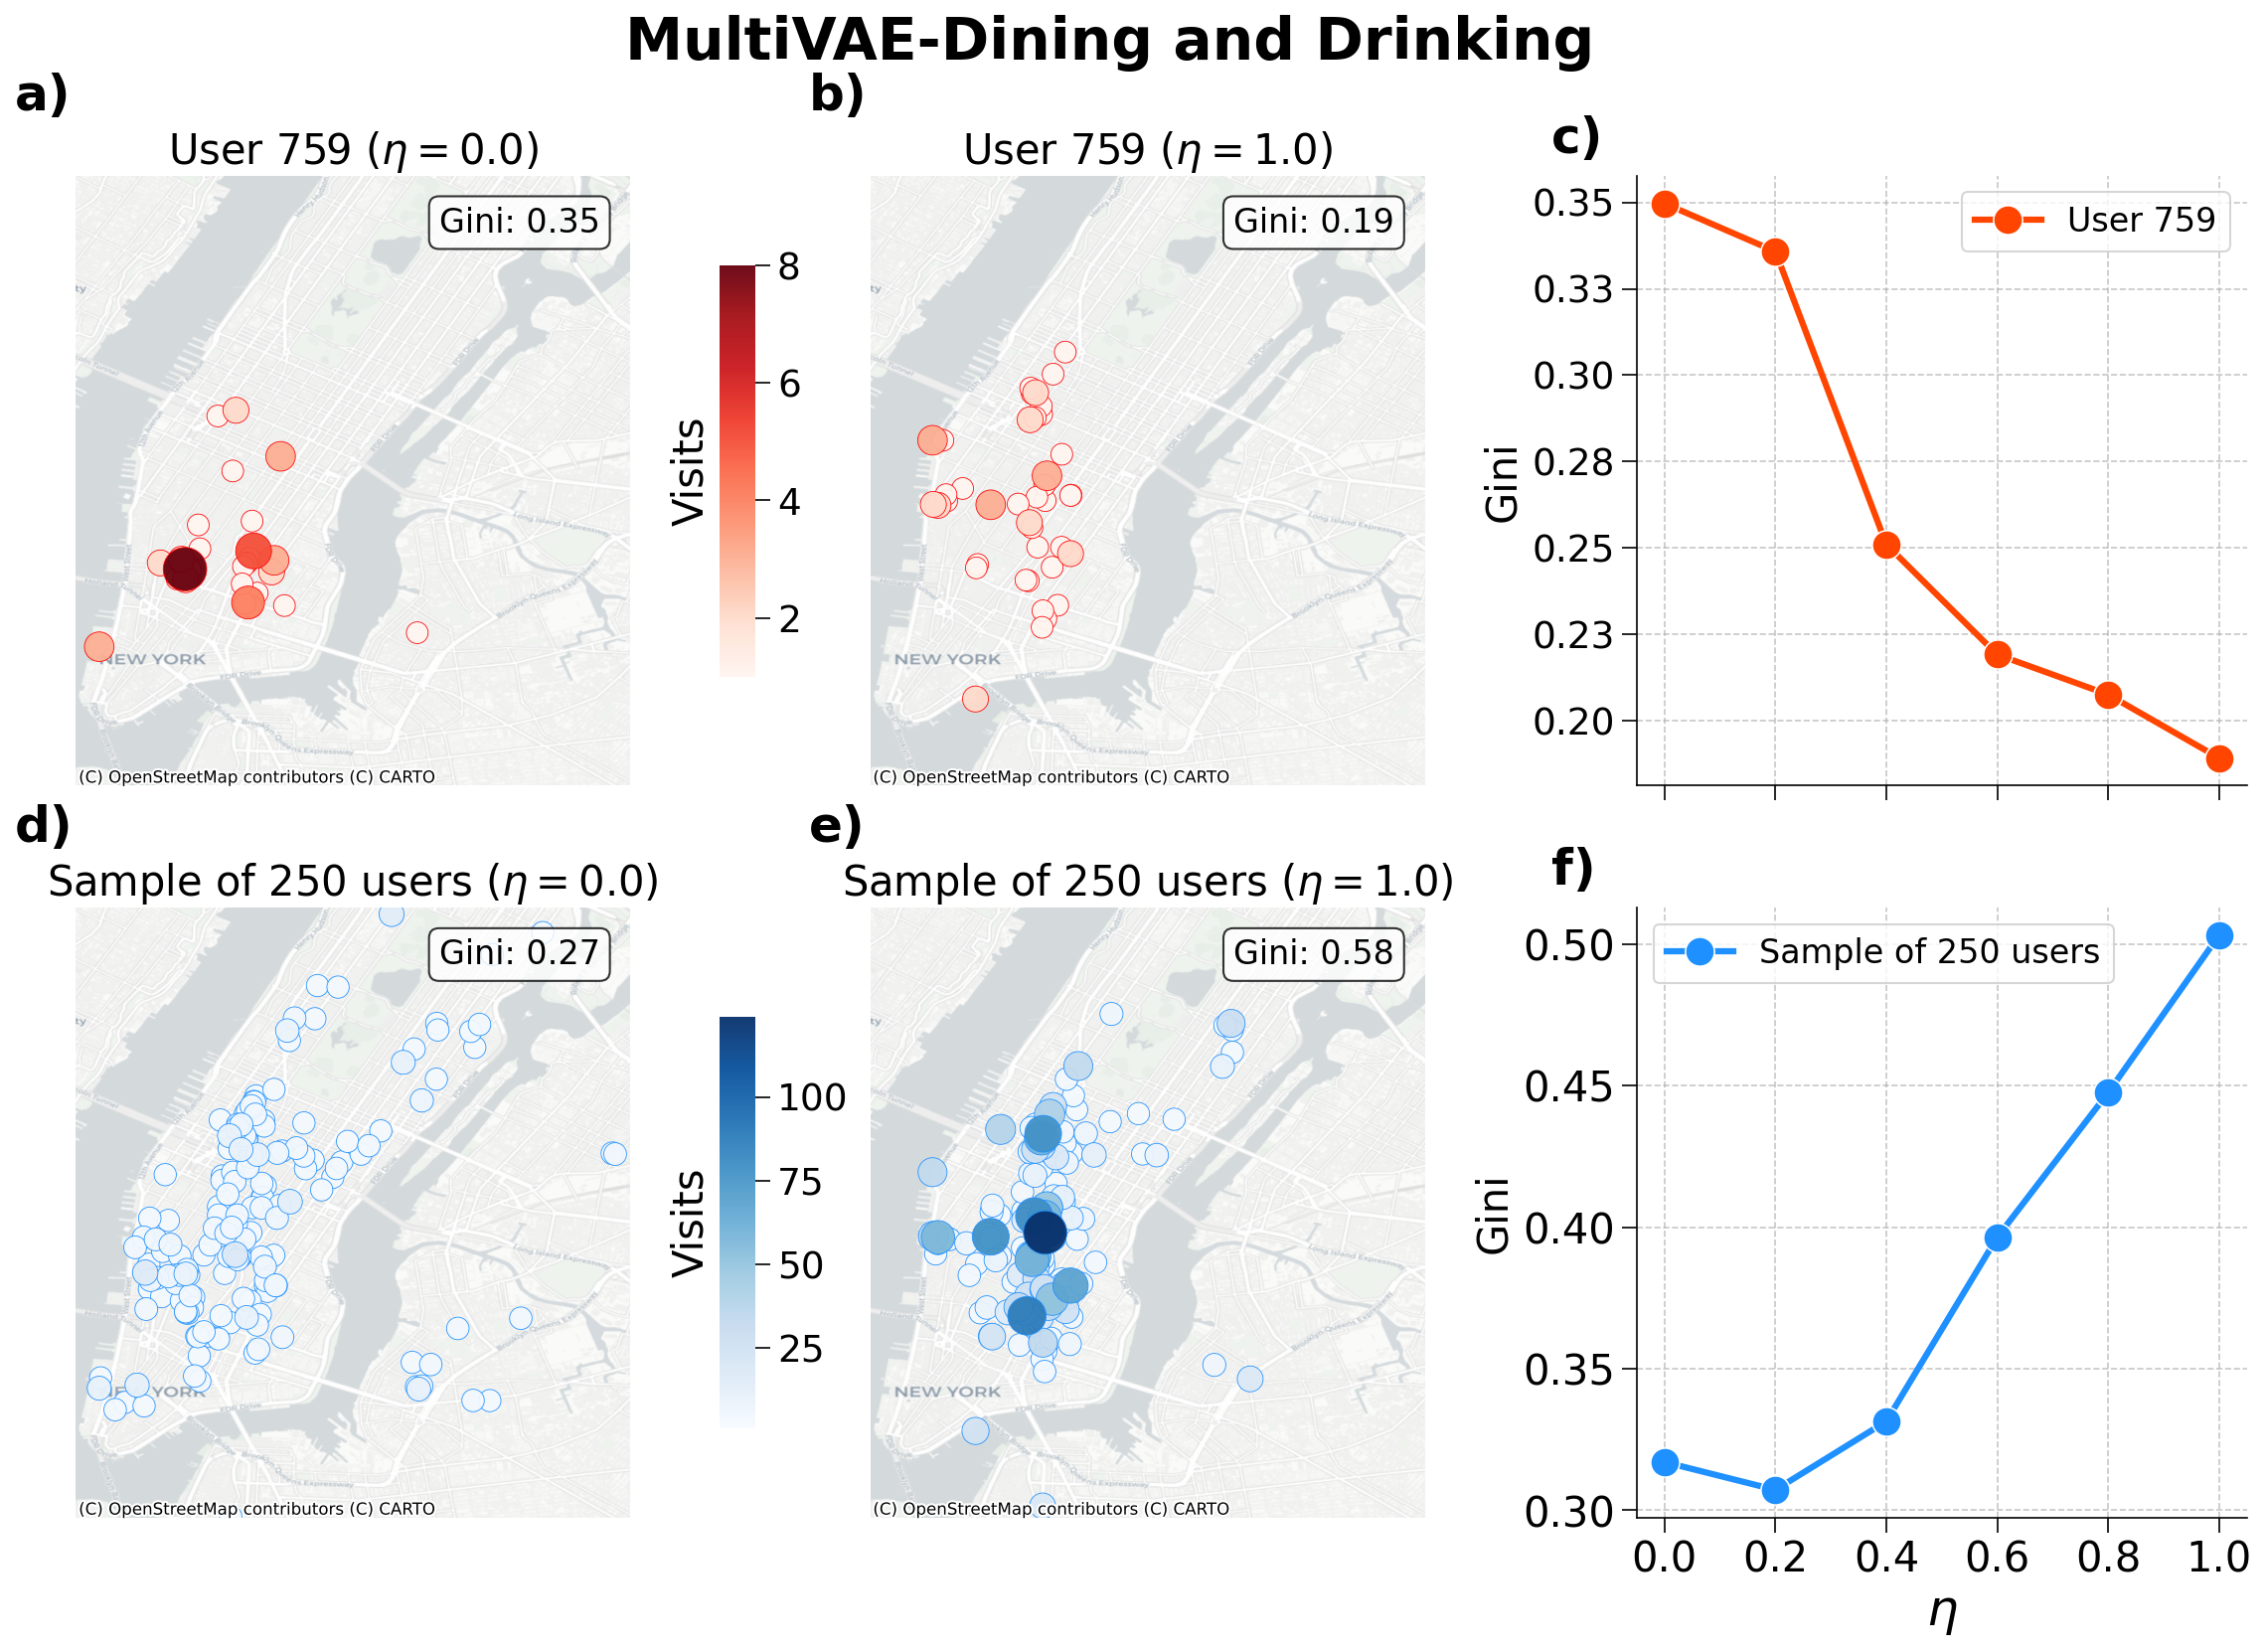

In [66]:
import contextily as ctx
import seaborn as sns

# --- Create figure ---
fig = plt.figure(figsize=(20, 12), dpi=150)

# --- Define grid for main plots ---
gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 1], wspace=0.1, hspace=0.2)

# --- Create subplots ---
ax_ind_p0 = fig.add_subplot(gs[0, 0])
ax_ind_p1 = fig.add_subplot(gs[0, 1])
ax_gini_ind = fig.add_subplot(gs[0, 2])

ax_coll_p0 = fig.add_subplot(gs[1, 0])
ax_coll_p1 = fig.add_subplot(gs[1, 1])
ax_gini_coll = fig.add_subplot(gs[1, 2])

# --- Plot individual p=0.0 ---
scatter_ind_0 = plot_user_visits_of_category(ax_ind_p0, user_history_p0, cmap='Reds', vmin=individual_vmin, vmax=individual_vmax, category=category)
ax_ind_p0.set_xlim(city_bounds['lon_min'], city_bounds['lon_max'])
ax_ind_p0.set_ylim(city_bounds['lat_min'], city_bounds['lat_max'])
ax_ind_p0.set_aspect(1)
ctx.add_basemap(ax_ind_p0, crs='EPSG:4326', source=ctx.providers.CartoDB.Positron)
ax_ind_p0.set_xticks([])
ax_ind_p0.set_yticks([])
ax_ind_p0.axis('off')
ax_ind_p0.set_title(f'User {random_user_id} $(\eta=0.0)$', fontsize=20)


# --- Plot individual p=1.0 ---
scatter_ind_1 = plot_user_visits_of_category(ax_ind_p1, user_history_p1, cmap='Reds', vmin=individual_vmin, vmax=individual_vmax, category=category)
ax_ind_p1.set_xlim(city_bounds['lon_min'], city_bounds['lon_max'])
ax_ind_p1.set_ylim(city_bounds['lat_min'], city_bounds['lat_max'])
ax_ind_p1.set_aspect(1)
ctx.add_basemap(ax_ind_p1, crs='EPSG:4326', source=ctx.providers.CartoDB.Positron)
ax_ind_p1.set_xticks([])
ax_ind_p1.set_yticks([])
ax_ind_p1.axis('off')
ax_ind_p1.set_title(f'User {random_user_id} $(\eta=1.0)$', fontsize=20)


# --- Plot collective p=0.0 ---
scatter_coll_0 = plot_collective_visits(ax_coll_p0, location_counts_p0, cmap='Blues', vmin=collective_vmin, vmax=collective_vmax, min_threshold=3)
ax_coll_p0.set_xlim(city_bounds['lon_min'], city_bounds['lon_max'])
ax_coll_p0.set_ylim(city_bounds['lat_min'], city_bounds['lat_max'])
ax_coll_p0.set_aspect(1)
ctx.add_basemap(ax_coll_p0, crs='EPSG:4326', source=ctx.providers.CartoDB.Positron)
ax_coll_p0.set_xticks([])
ax_coll_p0.set_yticks([])
ax_coll_p0.axis('off')
ax_coll_p0.set_title(r'Sample of 250 users $(\eta=0.0)$', fontsize=20)


# --- Plot collective p=1.0 ---
scatter_coll_1 = plot_collective_visits(ax_coll_p1, location_counts_p1, cmap='Blues', vmin=collective_vmin, vmax=collective_vmax, min_threshold=3)
ax_coll_p1.set_xlim(city_bounds['lon_min'], city_bounds['lon_max'])
ax_coll_p1.set_ylim(city_bounds['lat_min'], city_bounds['lat_max'])
ax_coll_p1.set_aspect(1)
ctx.add_basemap(ax_coll_p1, crs='EPSG:4326', source=ctx.providers.CartoDB.Positron)
ax_coll_p1.set_xticks([])
ax_coll_p1.set_yticks([])
ax_coll_p1.axis('off')
ax_coll_p1.set_title(r'Sample of 250 users $(\eta=1.0)$', fontsize=20)


# --- Add colorbars with no border and label on the left ---
# Individual colorbar
cbar_ax_ind = fig.add_axes([0.369, 0.58, 0.012, 0.23])  # [left, bottom, width, height]
cbar_ax_ind.set_frame_on(False)  # Turn off the axes frame completely
cbar_ind = plt.colorbar(scatter_ind_0, cax=cbar_ax_ind)
cbar_ind.outline.set_visible(False)  # Remove the border
cbar_ind.ax.yaxis.set_label_position('left')  # Move label to left side
cbar_ind.set_label('Visits', fontsize=20)
#increase ticklabel size
cbar_ind.ax.tick_params(labelsize=18)  # Increase tick label size

# Collective colorbar
cbar_ax_coll = fig.add_axes([0.369, 0.16, 0.012, 0.23])  # [left, bottom, width, height]
cbar_ax_coll.set_frame_on(False)  # Turn off the axes frame completely
cbar_coll = plt.colorbar(scatter_coll_0, cax=cbar_ax_coll)
cbar_coll.outline.set_visible(False)  # Remove the border
cbar_coll.ax.yaxis.set_label_position('left')  # Move label to left side
cbar_coll.set_label('Visits', fontsize=20)
#increase ticklabel size
cbar_coll.ax.tick_params(labelsize=18)  # Increase tick label size

# --- Make the Gini plots square ---
# Set the aspect ratio to be equal (square)
ax_gini_ind.set_box_aspect(1.0)
ax_gini_coll.set_box_aspect(1.0)

# --- Plot Individual Gini ---
ax_gini_ind.grid(True, linestyle='--', alpha=0.7)
sns.lineplot(x=ps, y=[individual_gini_dict[p] for p in ps], marker='o', 
             color='orangered', ax=ax_gini_ind, linewidth=3, markersize=14)
sns.despine()
ax_gini_ind.set_title('')
ax_gini_ind.set_ylabel('Gini', fontsize=20)
ax_gini_ind.set_xlabel('', fontsize=20)
ax_gini_ind.legend([f'User {random_user_id}'], fontsize=16)
#shut down xticklabels
ax_gini_ind.set_xticklabels([])
ax_gini_ind.tick_params(axis='y', which='major', labelsize=18)
ax_gini_ind.yaxis.set_major_formatter(lambda x, pos: f'{x:.2f}')

# --- Plot Collective Gini ---
ax_gini_coll.grid(True, linestyle='--', alpha=0.7)
sns.lineplot(x=ps, y=[collective_gini_dict[p] for p in ps], marker='o', 
             color='dodgerblue', ax=ax_gini_coll, linewidth=3, markersize=14)
sns.despine()
ax_gini_coll.set_title('')
ax_gini_coll.set_ylabel('Gini', fontsize=20)
ax_gini_coll.set_xlabel('$\eta$', fontsize=24)
ax_gini_coll.legend(['Sample of 250 users'], fontsize=16)
#increase ticklabel and set 2 decimal 
#force x-asxis labels to be exactly [0, 0.2, 0.4, 0.6, 0.8, 1]
ax_gini_coll.set_xticks(ps)
ax_gini_coll.set_xticklabels([f'{p:.1f}' for p in ps], fontsize=22)

ax_gini_coll.tick_params(axis='both', which='major', labelsize=20)
ax_gini_coll.yaxis.set_major_formatter(lambda x, pos: f'{x:.2f}')

# --- Overall title ---
plt.suptitle(f"{algorithm}-{category}", fontsize=28, fontweight='bold', y=0.95)


#titling of the subplots
letters = ['a', 'b', 'c', 'd', 'e', 'f']
for i, ax in enumerate([ax_ind_p0, ax_ind_p1, ax_gini_ind, ax_coll_p0, ax_coll_p1 , ax_gini_coll]):
        if i!= 2 and i!=5:
                ax.text(-0.11, 1.17, f"{letters[i]})", transform=ax.transAxes, 
                fontsize=24, fontweight='bold', va='top', ha='left', color='black')
        else:
                ax.text(-0.14, 1.10, f"{letters[i]})", transform=ax.transAxes, 
                fontsize=24, fontweight='bold', va='top', ha='left', color='black')

# --- Final adjustments ---
plt.tight_layout()
plt.subplots_adjust(top=0.86)  # Make room for the title
plt.savefig(f"figures/{city}/{algorithm}_Spatial.pdf", bbox_inches='tight', dpi = 300)

plt.show()

In [72]:
all_categories

['Arts and Entertainment',
 'Business and Professional Services',
 'Community and Government',
 'Dining and Drinking',
 'Health and Medicine',
 'Landmarks and Outdoors',
 'Nightlife Spot',
 'Retail',
 'Sports and Recreation',
 'Travel and Transportation']

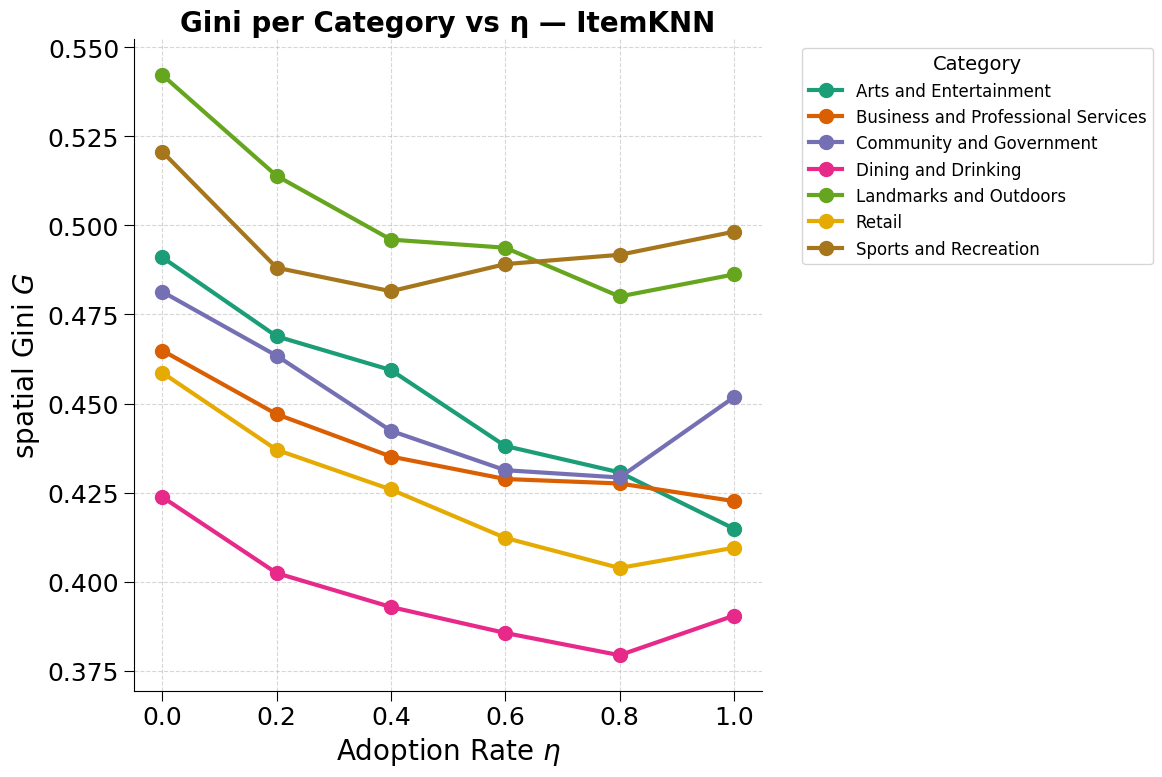

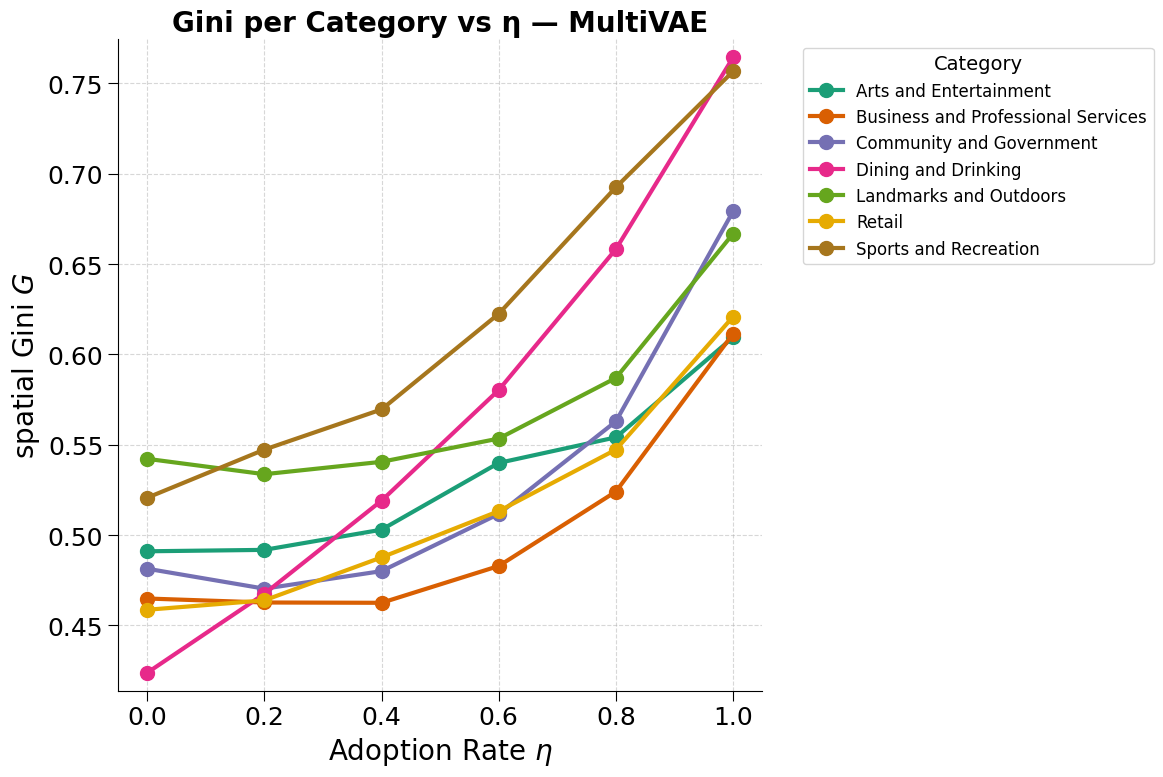

In [96]:
import matplotlib.pyplot as plt
import numpy as np

# === Style Setup ===
plt.style.use('default')
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 20,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 14,
    'figure.figsize': (12, 8),
    'xtick.major.size': 7,
    'ytick.major.size': 7,
})

# === Plot: One per algorithm ===
for algorithm in algorithms:
    fig, ax = plt.subplots()

    # Collect all categories
    all_categories = set()
    for p in ps:
        all_categories.update(gini_indices_by_category[algorithm][p].keys())
    all_categories = sorted(all_categories)
    all_categories.remove("Nightlife Spot")
    all_categories.remove("Travel and Transportation")
    all_categories.remove("Health and Medicine")

    # Prepare lines
    min_val = float('inf')
    max_val = float('-inf')

    for category in all_categories:
        y = []
        for p in ps:
            val = gini_indices_by_category[algorithm][p].get(category, np.nan)
            y.append(val)
            if not np.isnan(val):
                min_val = min(min_val, val)
                max_val = max(max_val, val)

        # Use a color palette for categories
        palette = plt.get_cmap('Dark2')
        color = palette(all_categories.index(category) % 10)
        ax.plot(ps, y, marker='o', label=category, linewidth=3, markersize=10, color=color)

    # Format plot
    ax.set_title(f"Gini per Category vs η — {algorithm}", fontsize=20, fontweight='bold')
    ax.set_xlabel(r"Adoption Rate $\eta$")
    ax.set_ylabel(r"spatial Gini $G$")
    ax.set_xticks(ps)
    ax.set_ylim(min_val - 0.01, max_val + 0.01)
    ax.grid(True, linestyle='--', alpha=0.5)

    # Remove spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Legend
    ax.legend(title="Category", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

    plt.tight_layout()
    plt.show()


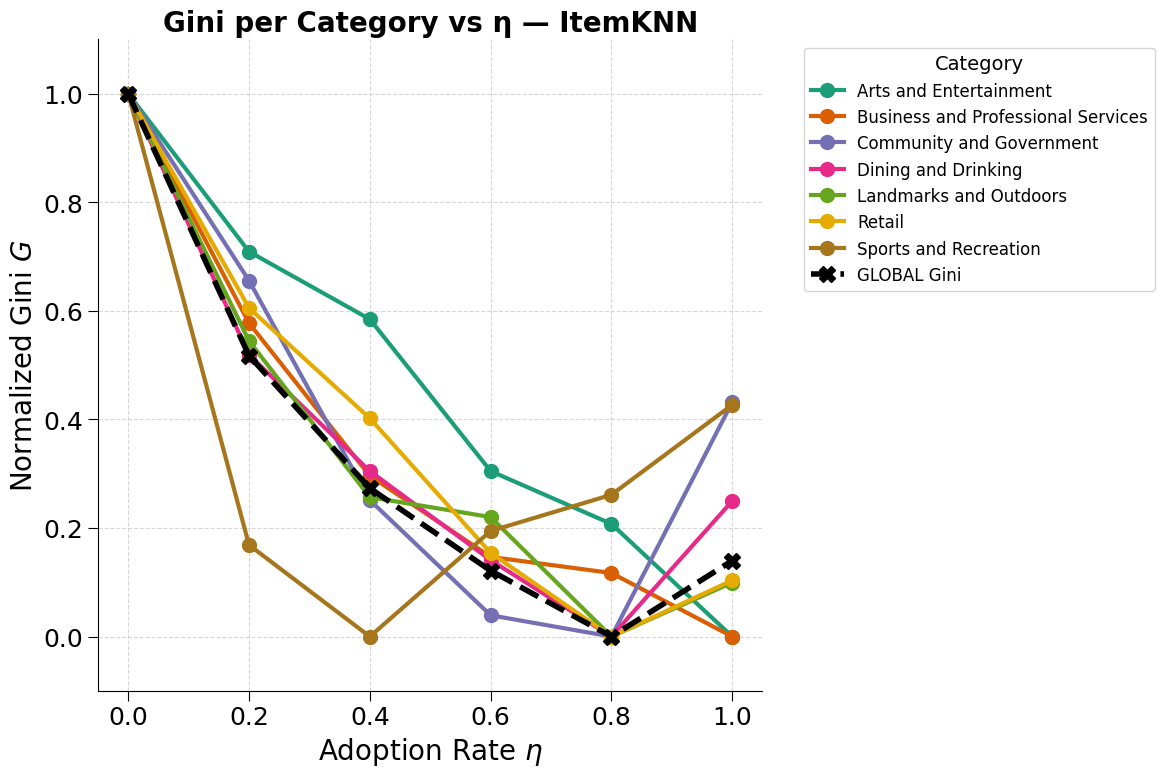

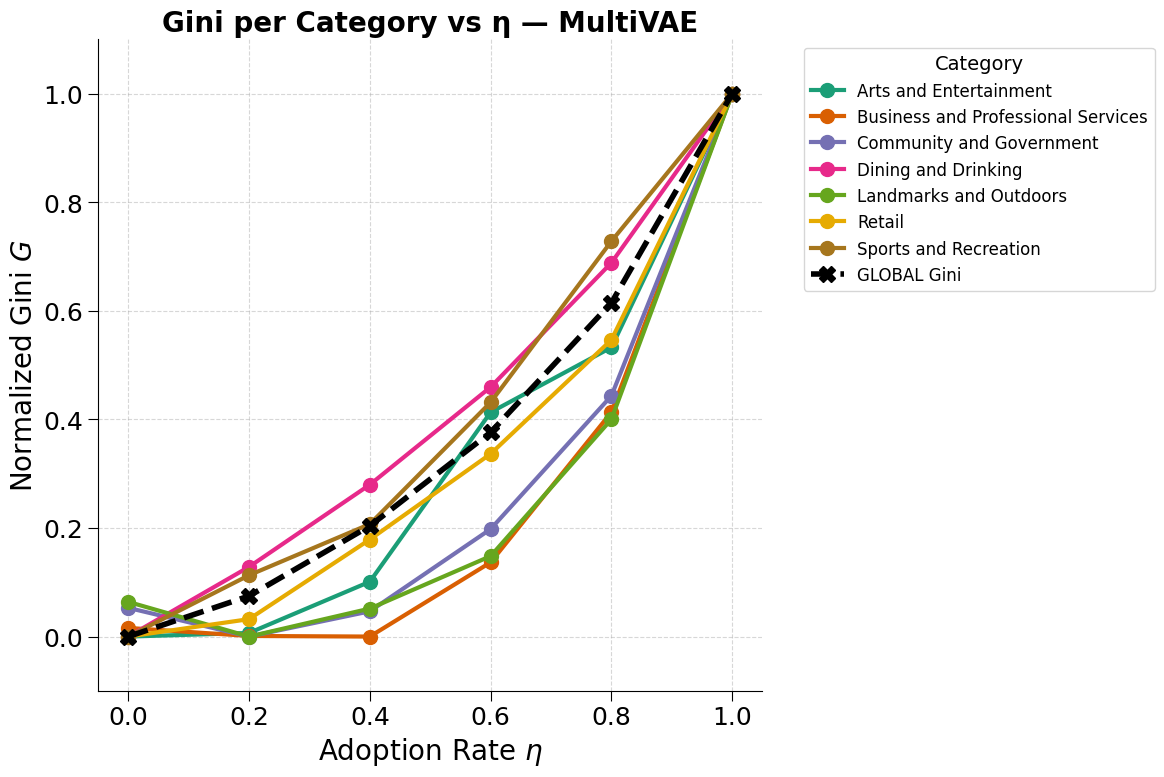

In [103]:
import matplotlib.pyplot as plt
import numpy as np

# === Style Setup ===
plt.style.use('default')
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 20,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 14,
    'figure.figsize': (12, 8),
    'xtick.major.size': 7,
    'ytick.major.size': 7,
})

def gini_index(x):
    """Compute Gini index from an array of counts."""
    x = np.array(x, dtype=np.float64)
    x = x[x > 0]  # ignore zeros
    if len(x) == 0:
        return np.nan
    x = np.sort(x)
    n = len(x)
    cumx = np.cumsum(x)
    return (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n

# === Plot: One per algorithm ===
for algorithm in algorithms:
    fig, ax = plt.subplots()

    # Collect all categories
    all_categories = set()
    for p in ps:
        all_categories.update(gini_indices_by_category[algorithm][p].keys())
    all_categories = sorted(all_categories)
    all_categories.remove("Nightlife Spot")
    all_categories.remove("Travel and Transportation")
    all_categories.remove("Health and Medicine")

    # === Plot per-category normalized curves ===
    for category in all_categories:
        y = []
        for p in ps:
            val = gini_indices_by_category[algorithm][p].get(category, np.nan)
            y.append(val)

        y = np.array(y, dtype=np.float64)
        valid_y = y[~np.isnan(y)]

        if len(valid_y) < 2:
            continue

        ymin, ymax = np.nanmin(valid_y), np.nanmax(valid_y)
        if ymax > ymin:
            y_norm = (y - ymin) / (ymax - ymin)
        else:
            y_norm = np.zeros_like(y)

        palette = plt.get_cmap('Dark2')
        color = palette(all_categories.index(category) % 10)
        ax.plot(ps, y_norm, marker='o', label=category,
                linewidth=3, markersize=10, color=color)

    # === Compute and normalize GLOBAL Gini ===
    global_ginis = []
    for p in ps:
        df = merged_histories_dict[(algorithm, p)]
        counts = df.groupby(['lat', 'lon']).size().values
        g = gini_index(counts)
        global_ginis.append(g)

    global_ginis = np.array(global_ginis)
    valid_g = global_ginis[~np.isnan(global_ginis)]
    if len(valid_g) >= 2 and np.nanmax(valid_g) > np.nanmin(valid_g):
        global_norm = (global_ginis - np.nanmin(valid_g)) / (np.nanmax(valid_g) - np.nanmin(valid_g))
    else:
        global_norm = np.zeros_like(global_ginis)

    # Plot global Gini
    ax.plot(ps, global_norm, linestyle='--', linewidth=4, marker='X',
            markersize=12, color='black', label='GLOBAL Gini')

    # === Format plot ===
    ax.set_title(f"Gini per Category vs η — {algorithm}", fontsize=20, fontweight='bold')
    ax.set_xlabel(r"Adoption Rate $\eta$")
    ax.set_ylabel(r"Normalized Gini $G$")
    ax.set_xticks(ps)
    ax.set_ylim(-0.1, 1.1)
    ax.grid(True, linestyle='--', alpha=0.5)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.legend(title="Category", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

    plt.tight_layout()
    plt.show()
